# Business Model Canvas Block Detection 

This notebook focuses on detecting the 9 blocks of the Business Model Canvas (BMC) using two object detection approaches:

- YOLOv8 (CNN-based detector)
- RT-DETR (Transformer-based detector)

The objective is to compare both architectures and evaluate their performance on structured document understanding.

This module is part of a larger pipeline:
BMC Image → Block Detection → OCR → Text Classification → LLM Generation

## Problem Definition
Given an input image (scanned BMC, board, or template), the goal is to:
- Detect each block
- Assign it to the correct class
- Extract its bounding box

This is formulated as an **object detection problem**.

In [2]:
!pip install -q ultralytics opencv-python-headless albumentations torchmetrics pytesseract
!apt-get install -q tesseract-ocr tesseract-ocr-fra 2>/dev/null

import os, glob, shutil, yaml, random, json, math
from pathlib import Path
from collections import Counter, defaultdict

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from ultralytics import YOLO, RTDETR

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = 0 if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 39.4 MB/s eta 0:00:00
Reading package lists...
Building dependency tree...
Reading state information...
tesseract-ocr is already the newest version (4.1.1-2.1build1).
The following NEW packages will be installed:
  tesseract-ocr-fra
0 upgraded, 1 newly installed, 0 to remove and 133 not upgraded.
Need to get 527 kB of archives.
After this operation, 1,145 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr-fra all 1:4.00~git30-7274cfa-1.1 [527 kB]
Fetched 527 kB in 1s (464 kB/s)
Selecting previously unselected package tesseract-ocr-fra.
(Reading database ... 124626 files and directories currently installed.)
Preparing to unpack .../tesseract-ocr-fra_1%3a4.00~git30-7274cfa-1.1_all.deb ...
Unpacking tesseract-ocr-fra (1:4.00~git30-7274cfa-1.1) ...
Setting up tesseract-ocr-fra (1:4.00~git30-7274cfa-1.1) ...
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics

## Configuration

This section defines the main parameters used throughout the notebook.

We specify:
- The dataset location
- The working directory where trained models and outputs will be saved
- The list of BMC block classes
- The number of classes
- The models to train: YOLOv8n, YOLOv8s, and RT-DETR
- Image sizes used for fast and high-resolution training
- Training parameters such as epochs and patience

In [7]:
DATASET_ROOT = Path('/kaggle/input/datasets/jihenedorgham/bmc-datast/dataset')

WORK_DIR = Path('/kaggle/working')
PROJECT_DIR = WORK_DIR / 'bmc_detector_models'
AUG_DATASET_ROOT = WORK_DIR / 'dataset_bmc_augmented'

CLASS_NAMES = [
    'customer_segments',
    'value_propositions',
    'channels',
    'customer_relationships',
    'revenue_streams',
    'key_resources',
    'key_activities',
    'key_partnerships',
    'cost_structure',
]
NC = len(CLASS_NAMES)

RUN_YOLOV8N = True
RUN_YOLOV8S = True
RUN_RTDETR = True        

IMG_SIZE_FAST = 640
IMG_SIZE_HIGH = 1024
EPOCHS = 80
PATIENCE = 15


## Data Preprocessing

In this step, we automatically detect the dataset structure to ensure it follows a valid YOLO format.

YOLO datasets may have different structures, so we automatically detect and load the correct paths for training, validation, and testing.


In [8]:
def detect_yolo_structure(root: Path):
    candidates = {
        'split_first': {
            'train_img': root/'train'/'images', 'train_lbl': root/'train'/'labels',
            'val_img': root/'val'/'images',     'val_lbl': root/'val'/'labels',
            'test_img': root/'test'/'images',   'test_lbl': root/'test'/'labels',
        },
        'type_first': {
            'train_img': root/'images'/'train', 'train_lbl': root/'labels'/'train',
            'val_img': root/'images'/'val',     'val_lbl': root/'labels'/'val',
            'test_img': root/'images'/'test',   'test_lbl': root/'labels'/'test',
        }
    }
    for name, paths in candidates.items():
        if paths['train_img'].exists() and paths['train_lbl'].exists() and paths['val_img'].exists():
            return name, paths
    raise FileNotFoundError(f'Could not detect YOLO folder structure under: {root}')

STRUCTURE, PATHS = detect_yolo_structure(DATASET_ROOT)
print('Detected structure:', STRUCTURE)
for k, v in PATHS.items():
    print(f'{k}: {v} | exists={v.exists()}')


Detected structure: split_first
train_img: /kaggle/input/datasets/jihenedorgham/bmc-datast/dataset/train/images | exists=True
train_lbl: /kaggle/input/datasets/jihenedorgham/bmc-datast/dataset/train/labels | exists=True
val_img: /kaggle/input/datasets/jihenedorgham/bmc-datast/dataset/val/images | exists=True
val_lbl: /kaggle/input/datasets/jihenedorgham/bmc-datast/dataset/val/labels | exists=True
test_img: /kaggle/input/datasets/jihenedorgham/bmc-datast/dataset/test/images | exists=True
test_lbl: /kaggle/input/datasets/jihenedorgham/bmc-datast/dataset/test/labels | exists=True


## Dataset Audit

We verify images, labels, and class distribution to detect any data issues before training.

In [9]:
IMG_EXTS = ['*.jpg', '*.jpeg', '*.png', '*.bmp', '*.webp']

def list_images(folder):
    files = []
    for ext in IMG_EXTS:
        files.extend(glob.glob(str(folder / ext)))
    return sorted(files)

def label_path_for_image(img_path, img_dir, lbl_dir):
    return str(lbl_dir / (Path(img_path).stem + '.txt'))

def read_yolo_labels(label_path):
    rows = []
    if not os.path.exists(label_path):
        return rows
    with open(label_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            cls, x, y, w, h = parts
            rows.append((int(float(cls)), float(x), float(y), float(w), float(h)))
    return rows

def audit_split(split, img_dir, lbl_dir):
    imgs = list_images(img_dir)
    missing = 0
    empty = 0
    class_counts = Counter()
    box_areas = []
    for img in imgs:
        lp = label_path_for_image(img, img_dir, lbl_dir)
        labels = read_yolo_labels(lp)
        if not os.path.exists(lp): missing += 1
        if len(labels) == 0: empty += 1
        for cls, x, y, w, h in labels:
            class_counts[cls] += 1
            box_areas.append(w*h)
    return {
        'split': split,
        'images': len(imgs),
        'missing_label_files': missing,
        'empty_label_files': empty,
        'objects': sum(class_counts.values()),
        'class_counts': class_counts,
        'mean_box_area': np.mean(box_areas) if box_areas else 0,
    }

audits = []
for split in ['train', 'val', 'test']:
    audits.append(audit_split(split, PATHS[f'{split}_img'], PATHS[f'{split}_lbl']))

summary_df = pd.DataFrame([{k:v for k,v in a.items() if k != 'class_counts'} for a in audits])
display(summary_df)

class_table = []
for a in audits:
    for cls_id, name in enumerate(CLASS_NAMES):
        class_table.append({'split': a['split'], 'class': name, 'count': a['class_counts'].get(cls_id, 0)})
class_df = pd.DataFrame(class_table)
display(class_df.pivot(index='class', columns='split', values='count').fillna(0).astype(int))


,split,images,missing_label_files,empty_label_files,objects,mean_box_area
0,train,1074,0,0,9666,0.096615
1,val,423,0,0,3807,0.097379
2,test,230,0,0,2070,0.096566


split,test,train,val
class,,,
channels,230,1074,423
cost_structure,230,1074,423
customer_relationships,230,1074,423
customer_segments,230,1074,423
key_activities,230,1074,423
key_partnerships,230,1074,423
key_resources,230,1074,423
revenue_streams,230,1074,423
value_propositions,230,1074,423


Train-Val duplicate filenames: 330
Train-Test duplicate filenames: 177
Val-Test duplicate filenames: 48


## YAML Setup

We create a YAML file to define dataset paths and class names for training.

In [10]:
DATA_YAML_ORIGINAL = WORK_DIR / 'data_bmc_original.yaml'

fixed_yaml = {
    'train': str(PATHS['train_img']),
    'val': str(PATHS['val_img']),
    'test': str(PATHS['test_img']),
    'nc': NC,
    'names': CLASS_NAMES,
}
with open(DATA_YAML_ORIGINAL, 'w') as f:
    yaml.safe_dump(fixed_yaml, f, sort_keys=False)

print('Created:', DATA_YAML_ORIGINAL)
print(yaml.safe_dump(fixed_yaml, sort_keys=False))


Created: /kaggle/working/data_bmc_original.yaml
train: /kaggle/input/datasets/jihenedorgham/bmc-datast/dataset/train/images
val: /kaggle/input/datasets/jihenedorgham/bmc-datast/dataset/val/images
test: /kaggle/input/datasets/jihenedorgham/bmc-datast/dataset/test/images
nc: 9
names:
- customer_segments
- value_propositions
- channels
- customer_relationships
- revenue_streams
- key_resources
- key_activities
- key_partnerships
- cost_structure



## Data Augmentation

We apply augmentation only on the training set to improve generalization.

Transformations include:
- small rotations and affine changes
- slight perspective distortion
- brightness and color variations
- blur and compression noise

This simulates real-world variations while keeping validation and test data unchanged for fair evaluation.

In [11]:
import albumentations as A

USE_AUGMENTED_TRAIN = True
N_AUG_PER_IMAGE = 2   # keep moderate; too much synthetic augmentation can hurt

transform = A.Compose([
    A.Rotate(limit=7, border_mode=cv2.BORDER_CONSTANT, p=0.55),
    A.Affine(scale=(0.90, 1.10), translate_percent=(-0.05, 0.05), shear=(-3, 3), p=0.55),
    A.Perspective(scale=(0.01, 0.025), p=0.18),
    A.RandomBrightnessContrast(brightness_limit=0.18, contrast_limit=0.18, p=0.45),
    A.HueSaturationValue(hue_shift_limit=5, sat_shift_limit=20, val_shift_limit=20, p=0.25),
    A.GaussianBlur(blur_limit=(3, 3), p=0.12),
    A.ImageCompression(quality_range=(70, 95), p=0.20),
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels'], min_visibility=0.35))

def copy_split_to_aug(split):
    out_img = AUG_DATASET_ROOT / split / 'images'
    out_lbl = AUG_DATASET_ROOT / split / 'labels'
    out_img.mkdir(parents=True, exist_ok=True)
    out_lbl.mkdir(parents=True, exist_ok=True)
    for img in list_images(PATHS[f'{split}_img']):
        shutil.copy2(img, out_img / Path(img).name)
        lp = label_path_for_image(img, PATHS[f'{split}_img'], PATHS[f'{split}_lbl'])
        if os.path.exists(lp):
            shutil.copy2(lp, out_lbl / Path(lp).name)

if USE_AUGMENTED_TRAIN:
    if AUG_DATASET_ROOT.exists():
        shutil.rmtree(AUG_DATASET_ROOT)
    for split in ['train', 'val', 'test']:
        copy_split_to_aug(split)

    train_imgs = list_images(PATHS['train_img'])
    added = 0
    for img_path in train_imgs:
        img = cv2.imread(img_path)
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        label_path = label_path_for_image(img_path, PATHS['train_img'], PATHS['train_lbl'])
        rows = read_yolo_labels(label_path)
        if not rows:
            continue
        boxes = [[x,y,w,h] for cls,x,y,w,h in rows]
        classes = [cls for cls,x,y,w,h in rows]
        for k in range(N_AUG_PER_IMAGE):
            try:
                aug = transform(image=img, bboxes=boxes, class_labels=classes)
                if len(aug['bboxes']) == 0:
                    continue
                stem = Path(img_path).stem
                new_img_name = f'{stem}_aug{k}.jpg'
                new_lbl_name = f'{stem}_aug{k}.txt'
                out_img_path = AUG_DATASET_ROOT / 'train' / 'images' / new_img_name
                out_lbl_path = AUG_DATASET_ROOT / 'train' / 'labels' / new_lbl_name
                cv2.imwrite(str(out_img_path), cv2.cvtColor(aug['image'], cv2.COLOR_RGB2BGR))
                with open(out_lbl_path, 'w') as f:
                    for cls, box in zip(aug['class_labels'], aug['bboxes']):
                        x,y,w,h = box
                        x,y,w,h = [min(max(float(v), 0.0), 1.0) for v in [x,y,w,h]]
                        f.write(f"{int(cls)} {x:.6f} {y:.6f} {w:.6f} {h:.6f}\n")

                added += 1
            except Exception as e:
                pass
    print('Augmented train images added:', added)
else:
    print('Augmentation disabled.')


Augmented train images added: 2148


In [12]:
# ============================================================
# 6) YAML FOR AUGMENTED DATASET
# ============================================================
DATA_YAML_AUG = WORK_DIR / 'data_bmc_augmented.yaml'

if USE_AUGMENTED_TRAIN:
    aug_yaml = {
        'train': str(AUG_DATASET_ROOT / 'train' / 'images'),
        'val': str(AUG_DATASET_ROOT / 'val' / 'images'),
        'test': str(AUG_DATASET_ROOT / 'test' / 'images'),
        'nc': NC,
        'names': CLASS_NAMES,
    }
    with open(DATA_YAML_AUG, 'w') as f:
        yaml.safe_dump(aug_yaml, f, sort_keys=False)
    DATA_YAML = str(DATA_YAML_AUG)
else:
    DATA_YAML = str(DATA_YAML_ORIGINAL)

print('Using DATA_YAML:', DATA_YAML)
print(open(DATA_YAML).read())


Using DATA_YAML: /kaggle/working/data_bmc_augmented.yaml
train: /kaggle/working/dataset_bmc_augmented/train/images
val: /kaggle/working/dataset_bmc_augmented/val/images
test: /kaggle/working/dataset_bmc_augmented/test/images
nc: 9
names:
- customer_segments
- value_propositions
- channels
- customer_relationships
- revenue_streams
- key_resources
- key_activities
- key_partnerships
- cost_structure



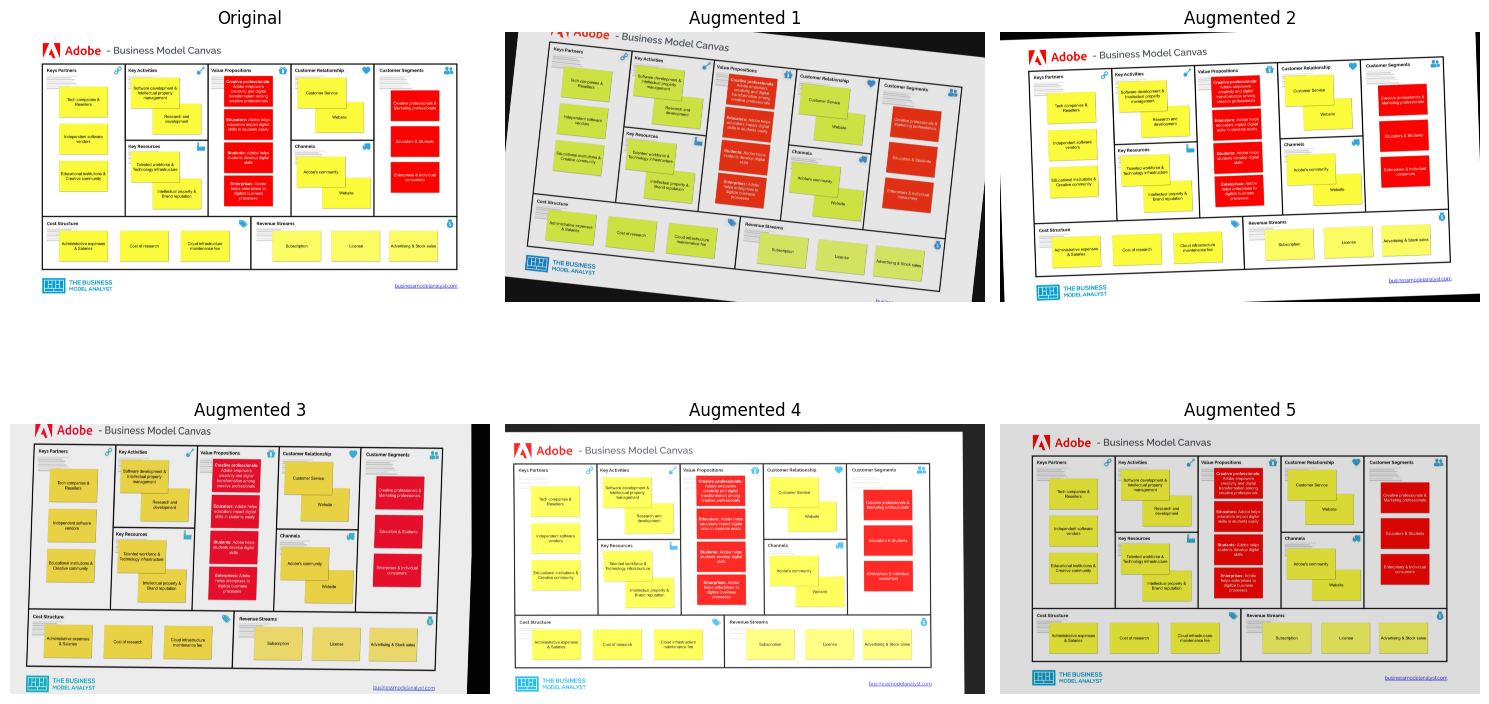

In [13]:
# ============================================================
# 7) AUGMENTATION PREVIEW
# ============================================================
sample_imgs = list_images(PATHS['train_img'])[:20]
if sample_imgs:
    img_path = random.choice(sample_imgs)
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    label_path = label_path_for_image(img_path, PATHS['train_img'], PATHS['train_lbl'])
    rows = read_yolo_labels(label_path)
    boxes = [[x,y,w,h] for cls,x,y,w,h in rows]
    classes = [cls for cls,x,y,w,h in rows]

    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    axes = axes.ravel()
    axes[0].imshow(img); axes[0].set_title('Original'); axes[0].axis('off')
    for i in range(1, 6):
        aug = transform(image=img, bboxes=boxes, class_labels=classes) if rows else {'image': img}
        axes[i].imshow(aug['image']); axes[i].set_title(f'Augmented {i}'); axes[i].axis('off')
    plt.tight_layout(); plt.show()
else:
    print('No training images found.')


##  Modeling

We use two object detection approaches:
- YOLOv8 (CNN-based)
- RT-DETR (Transformer-based)

YOLO predicts bounding boxes in a single pass and is optimized for speed, while RT-DETR uses self-attention to better capture global layout relationships.

This allows us to compare CNN vs Transformer performance for structured BMC detection.

## YOLOv8 Training

We define a reusable training function for YOLOv8 models.

We train:
- YOLOv8n: lightweight and faster
- YOLOv8s: larger and more accurate

Regularization and moderate augmentations are used to reduce overfitting while preserving the fixed BMC layout.

In [11]:
# ============================================================
# 8) YOLO TRAINING FUNCTION
# ============================================================
def train_yolo_model(weights, run_name, imgsz=640, batch=8, lr0=1e-4, dropout=0.10):
    model = YOLO(weights)
    results = model.train(
        data=DATA_YAML,
        epochs=EPOCHS,
        imgsz=imgsz,
        batch=batch,
        project=str(PROJECT_DIR),
        name=run_name,
        pretrained=True,

        #augmentation
        mosaic=0.45,
        close_mosaic=15,
        mixup=0.05,
        copy_paste=0.05,
        fliplr=0.0,
        flipud=0.0,
        degrees=5.0,
        translate=0.08,
        scale=0.25,
        shear=2.0,
        perspective=0.0004,
        hsv_h=0.01,
        hsv_s=0.25,
        hsv_v=0.25,
        erasing=0.20,

        optimizer='AdamW',
        lr0=lr0,
        lrf=0.01,
        weight_decay=0.01,
        warmup_epochs=5,
        cos_lr=True,
        dropout=dropout,
        patience=PATIENCE,
        val=True,
        plots=True,
        seed=SEED,
        deterministic=True,
        exist_ok=True,
    )
    return model, results


In [12]:
# ============================================================
# 9) TRAIN YOLO MODELS
# ============================================================
trained_models = []

if RUN_YOLOV8N:
    model_n, _ = train_yolo_model('yolov8n.pt', 'yolov8n_regularized', imgsz=IMG_SIZE_FAST, batch=8, lr0=1e-4, dropout=0.05)
    trained_models.append('yolov8n_regularized')

if RUN_YOLOV8S:
    model_s, _ = train_yolo_model('yolov8s.pt', 'yolov8s_regularized', imgsz=IMG_SIZE_HIGH, batch=4, lr0=7e-5, dropout=0.10)
    trained_models.append('yolov8s_regularized')

print('Finished YOLO runs:', trained_models)


Ultralytics 8.4.46 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=15, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.05, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/data_bmc_augmented.yaml, degrees=5.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.05, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.2, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.01, hsv_s=0.25, hsv_v=0.25, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.05, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=0.45, multi_scale=0.0, name=yolov8n_regularized, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, ove

## Model Evaluation

We evaluate YOLO models on both validation and test sets.

For each model, we compute:
- Precision: how many predicted boxes are correct
- Recall: how many real BMC blocks are detected
- mAP50: detection accuracy using IoU ≥ 0.5
- mAP50-95: stricter detection accuracy across multiple IoU thresholds


In [15]:
# ============================================================
# 12) ULTRALYTICS EVALUATION ON VAL + TEST
# ============================================================
def evaluate_ultralytics_model(weights_path, split='val', imgsz=1024):
    model = YOLO(weights_path) if 'rtdetr' not in str(weights_path).lower() else RTDETR(weights_path)
    res = model.val(
        data=DATA_YAML,
        split=split,
        imgsz=imgsz,
        conf=0.25,
        iou=0.60,
        plots=True,
        save_json=True,
        project=str(PROJECT_DIR),
        name=f'eval_{Path(weights_path).parents[1].name}_{split}',
        exist_ok=True,
    )
    return {
        'Model': Path(weights_path).parents[1].name,
        'Split': split,
        'Precision': float(res.box.mp),
        'Recall': float(res.box.mr),
        'mAP50': float(res.box.map50),
        'mAP50-95': float(res.box.map),
    }, res, model

eval_rows = []
val_objects = {}
for _, row in weights_df.iterrows():
    for split in ['val', 'test']:
        try:
            metrics, res, mdl = evaluate_ultralytics_model(row['weights'], split=split, imgsz=IMG_SIZE_HIGH)
            eval_rows.append(metrics)
            val_objects[(metrics['Model'], split)] = (res, mdl)
        except Exception as e:
            print('Evaluation failed for', row['run'], split, ':', e)

eval_df = pd.DataFrame(eval_rows).sort_values(['Split','mAP50'], ascending=[True, False])
display(eval_df)
eval_df.to_csv(WORK_DIR / 'ultralytics_model_evaluation.csv', index=False)


Ultralytics 8.4.46 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,007,403 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1019.5±704.2 MB/s, size: 306.2 KB)
val: Scanning /kaggle/working/dataset_bmc_augmented/val/labels.cache... 423 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 423/423 161.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 27/27 1.9it/s 14.2s0.2s
                   all        423       3807      0.949      0.922      0.938      0.768
     customer_segments        423        423      0.935      0.991      0.992      0.845
    value_propositions        423        423      0.918      0.936      0.956      0.779
              channels        423        423      0.998      0.956      0.965       0.82
customer_relationships        423        423      0.984      0.936      0.954       0.83
       revenue_streams 

,Model,Split,Precision,Recall,mAP50,mAP50-95
3,yolov8s_regularized,test,0.998097,0.999124,0.994947,0.981284
1,yolov8n_regularized,test,0.939709,0.943304,0.948198,0.776832
2,yolov8s_regularized,val,0.997465,0.999624,0.994976,0.983350
0,yolov8n_regularized,val,0.948982,0.921589,0.938153,0.767963


In [17]:
# ============================================================
# 13) PER-CLASS AP FOR BEST MODEL
# ============================================================
if len(eval_df):
    best_row = eval_df[eval_df['Split']=='val'].sort_values('mAP50', ascending=False).iloc[0]
    BEST_RUN = best_row['Model']
    BEST_WEIGHTS = weights_df.loc[weights_df['run'] == BEST_RUN, 'weights'].iloc[0]
    print('Best model by val mAP50:', BEST_RUN)
    print('Best weights:', BEST_WEIGHTS)

    res, mdl = val_objects[(BEST_RUN, 'val')]
    print('Per-class AP@50-95:')
    for i, name in mdl.names.items():
        ap = float(res.box.ap[i]) if hasattr(res.box, 'ap') and i < len(res.box.ap) else float('nan')
        print(f'{name:<30} {ap:.4f}')
else:
    BEST_WEIGHTS = weights_df.iloc[-1]['weights']
    print('No eval_df. Fallback BEST_WEIGHTS:', BEST_WEIGHTS)


Best model by val mAP50: yolov8s_regularized
Best weights: /kaggle/working/bmc_detector_models/yolov8s_regularized/weights/best.pt
Per-class AP@50-95:
customer_segments              0.9791
value_propositions             0.9821
channels                       0.9777
customer_relationships         0.9776
revenue_streams                0.9868
key_resources                  0.9852
key_activities                 0.9842
key_partnerships               0.9895
cost_structure                 0.9880


In [18]:
# ============================================================
# 14) TRAIN/VAL GAP DIAGNOSTIC FROM results.csv
# ============================================================
def load_results_csv(csv_path):
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()
    return df

run_summaries = []
for _, row in weights_df.iterrows():
    csv_path = row['results_csv']
    if not os.path.exists(csv_path):
        continue
    df = load_results_csv(csv_path)
    best_idx = df['metrics/mAP50(B)'].idxmax() if 'metrics/mAP50(B)' in df else len(df)-1
    last = df.iloc[best_idx]
    gap_box = None
    if 'train/box_loss' in df and 'val/box_loss' in df:
        gap_box = float(last['val/box_loss'] - last['train/box_loss'])
    run_summaries.append({
        'Model': row['run'],
        'Best Epoch': int(best_idx + 1),
        'Best mAP50': float(last.get('metrics/mAP50(B)', np.nan)),
        'Best mAP50-95': float(last.get('metrics/mAP50-95(B)', np.nan)),
        'Precision': float(last.get('metrics/precision(B)', np.nan)),
        'Recall': float(last.get('metrics/recall(B)', np.nan)),
        'Val-Train Box Loss Gap': gap_box,
    })

summary_runs_df = pd.DataFrame(run_summaries).sort_values('Best mAP50', ascending=False)
display(summary_runs_df)
summary_runs_df.to_csv(WORK_DIR / 'training_gap_summary.csv', index=False)


,Model,Best Epoch,Best mAP50,Best mAP50-95,Precision,Recall,Val-Train Box Loss Gap
1,yolov8s_regularized,28,0.99499,0.97013,0.99759,0.99856,-0.20338
0,yolov8n_regularized,35,0.99498,0.95340,0.99698,0.99872,-0.19384


In [2]:
# ============================================================
# EXPORT BEST YOLOv8n + YOLOv8s MODELS 
# ============================================================
from pathlib import Path
import shutil
import zipfile
import os

PROJECT_DIR = Path("/kaggle/working/bmc_detector_models")

MODELS_TO_EXPORT = {
    "yolov8n_regularized": PROJECT_DIR / "yolov8n_regularized" / "weights" / "best.pt",
    "yolov8s_regularized": PROJECT_DIR / "yolov8s_regularized" / "weights" / "best.pt",
}

EXPORT_DIR = Path("/kaggle/working/exported_yolo_models")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

for model_name, weight_path in MODELS_TO_EXPORT.items():
    if weight_path.exists():
        shutil.copy2(weight_path, EXPORT_DIR / f"{model_name}_best.pt")
        print(f" Exported: {model_name}")
    else:
        print(f" Missing weights for {model_name}: {weight_path}")

# also save class names / data.yaml if available
yaml_candidates = [
    Path("/kaggle/working/dataset_bmc_augmented/data.yaml"),
    Path("/kaggle/working/dataset_bmc/data.yaml"),
]

for yml in yaml_candidates:
    if yml.exists():
        shutil.copy2(yml, EXPORT_DIR / "data.yaml")
        print(" data.yaml exported")
        break

# zip everything
ZIP_PATH = "/kaggle/working/yolo_bmc_models_for_deployment.zip"

with zipfile.ZipFile(ZIP_PATH, "w", zipfile.ZIP_DEFLATED) as zipf:
    for file in EXPORT_DIR.rglob("*"):
        zipf.write(file, arcname=file.name)

print("ZIP ready:", ZIP_PATH)

✅ Exported: yolov8n_regularized
✅ Exported: yolov8s_regularized
✅ ZIP ready: /kaggle/working/yolo_bmc_models_for_deployment.zip


In [3]:
from IPython.display import FileLink
FileLink("/kaggle/working/yolo_bmc_models_for_deployment.zip")

/kaggle/working/yolo_bmc_models_for_deployment.zip

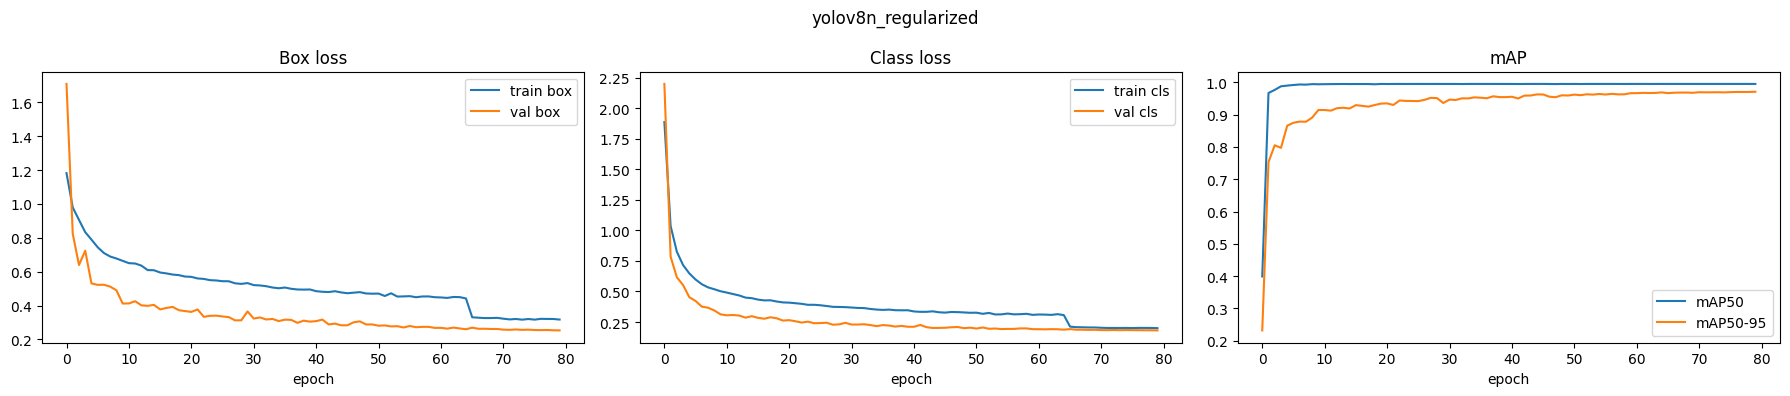

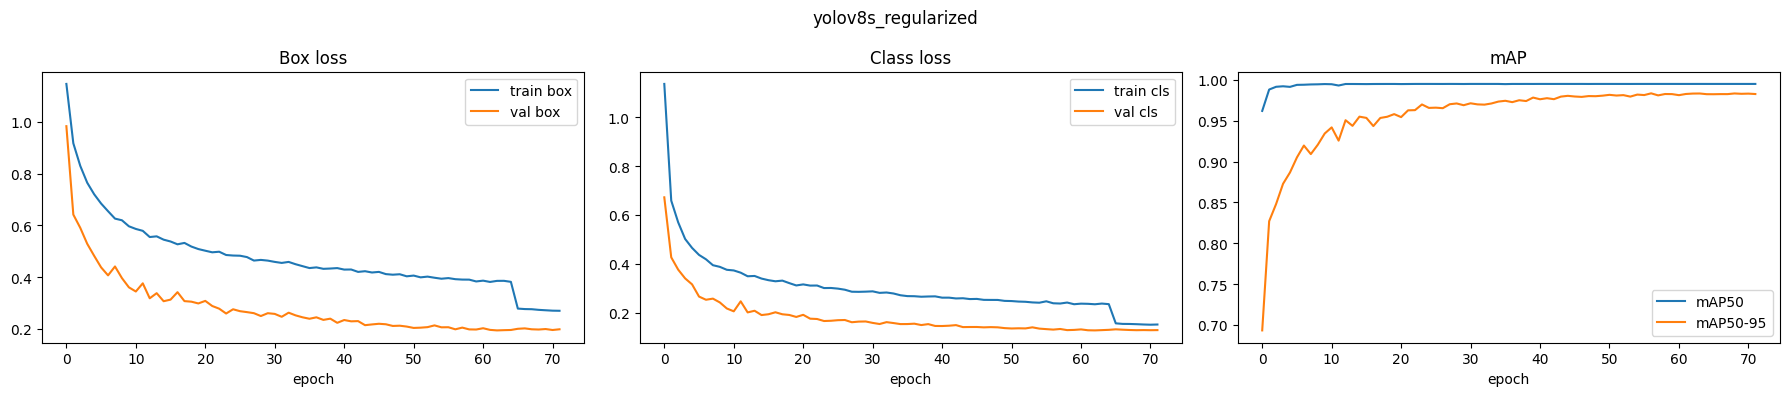

In [19]:
# ============================================================
# 15) PLOT TRAINING CURVES FOR EACH RUN
# ============================================================
for _, row in weights_df.iterrows():
    csv_path = row['results_csv']
    if not os.path.exists(csv_path):
        continue
    df = load_results_csv(csv_path)
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    fig.suptitle(row['run'])

    if 'train/box_loss' in df and 'val/box_loss' in df:
        axes[0].plot(df['train/box_loss'], label='train box')
        axes[0].plot(df['val/box_loss'], label='val box')
        axes[0].set_title('Box loss'); axes[0].legend()
    if 'train/cls_loss' in df and 'val/cls_loss' in df:
        axes[1].plot(df['train/cls_loss'], label='train cls')
        axes[1].plot(df['val/cls_loss'], label='val cls')
        axes[1].set_title('Class loss'); axes[1].legend()
    if 'metrics/mAP50(B)' in df:
        axes[2].plot(df['metrics/mAP50(B)'], label='mAP50')
        axes[2].plot(df['metrics/mAP50-95(B)'], label='mAP50-95')
        axes[2].set_title('mAP'); axes[2].legend()

    for ax in axes: ax.set_xlabel('epoch')
    plt.tight_layout(); plt.show()


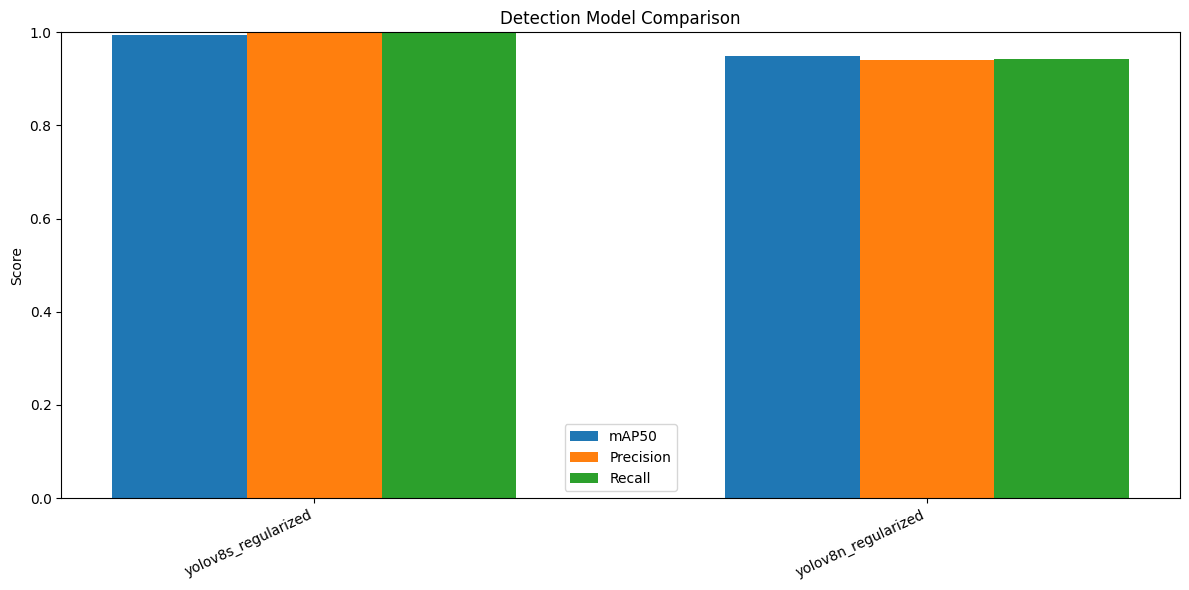

In [20]:
# ============================================================
# 16) MODEL COMPARISON BAR CHART
# ============================================================
if len(eval_df):
    plot_df = eval_df[eval_df['Split']=='test'].copy()
    if len(plot_df) == 0:
        plot_df = eval_df[eval_df['Split']=='val'].copy()
    plot_df = plot_df.sort_values('mAP50', ascending=False)

    x = np.arange(len(plot_df))
    width = 0.22
    plt.figure(figsize=(12, 6))
    plt.bar(x - width, plot_df['mAP50'], width, label='mAP50')
    plt.bar(x, plot_df['Precision'], width, label='Precision')
    plt.bar(x + width, plot_df['Recall'], width, label='Recall')
    plt.xticks(x, plot_df['Model'], rotation=25, ha='right')
    plt.ylim(0, 1)
    plt.ylabel('Score')
    plt.title('Detection Model Comparison')
    plt.legend()
    plt.tight_layout()
    plt.show()


## RT-DETR Training

We train **RT-DETR**, a **transformer-based object detector**.

Unlike YOLO, it uses self-attention to better capture global layout relationships, making it suitable for structured data like BMC.

However, it is more computationally expensive, so it is trained with smaller batch size.

In [16]:
# ============================================================
#  ALTERNATIVE MODEL 1 — RT-DETR
#============================================================
if RUN_RTDETR:
    model_rtdetr = RTDETR('/kaggle/working/rtdetr-l.pt')
    model_rtdetr.train(
        data=DATA_YAML,
        epochs=50,
        imgsz=IMG_SIZE_HIGH,
        batch=2,
        project=str(PROJECT_DIR),
        name='rtdetr_l_bmc',
        pretrained=True,
        optimizer='AdamW',
        lr0=5e-5,
        weight_decay=0.01,
        patience=10,
        plots=True,
        seed=SEED,
        exist_ok=True,
    )
    trained_models.append('rtdetr_l_bmc')
else:
    print('RT-DETR skipped. Set RUN_RTDETR=True to train it.')




Ultralytics 8.4.46 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data_bmc_augmented.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=5e-05, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/kaggle/working/rtdetr-l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=rtdetr_l_bmc, nbs=64, nms=False, opset=None, optimize=False, optimizer=Adam

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       1/50      7.89G      0.676      1.278     0.5367         46       1024: 100% ━━━━━━━━━━━━ 1611/1611 2.4it/s 11:19<0.4s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 106/106 4.2it/s 25.2s0.2s
                   all        423       3807     0.0254      0.291     0.0242     0.0145

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
       2/50      4.73G     0.5934      1.123     0.3535         55       1024: 0% ──────────── 0/1611  0.4s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       2/50      4.79G     0.3396      1.452     0.2423         40       1024: 100% ━━━━━━━━━━━━ 1611/1611 2.4it/s 11:04<0.4s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 106/106 5.3it/s 19.9s0.2s
                   all        423       3807     0.0386      0.492     0.0394     0.0297

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
       3/50      4.79G     0.2977      1.627     0.2217         23       1024: 0% ──────────── 0/1611  0.4s

...

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      49/50       4.8G     0.1074     0.1875    0.08971         18       1024: 100% ━━━━━━━━━━━━ 1611/1611 2.4it/s 11:03<0.4s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 106/106 5.5it/s 19.3s0.2s
                   all        423       3807      0.996      0.998      0.995      0.959

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      50/50       4.8G    0.04583     0.1127    0.02926         18       1024: 0% ──────────── 0/1611  0.4s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      50/50       4.8G     0.1036     0.1848    0.08459         18       1024: 100% ━━━━━━━━━━━━ 1611/1611 2.4it/s 11:08<0.4s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 106/106 5.6it/s 19.0s0.2s
                   all        423       3807      0.995      0.997      0.995       0.96

50 epochs completed in 9.521 hours.
Optimizer stripped from /kaggle/working/bmc_detector_models/rtdetr_l_bmc/weights/last.pt, 66.4MB
Optimizer stripped from /kaggle/working/bmc_detector_models/rtdetr_l_bmc/weights/best.pt, 66.4MB

Validating /kaggle/working/bmc_detector_models/rtdetr_l_bmc/weights/best.pt...
Ultralytics 8.4.46 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
rt-detr-l summary: 310 layers, 32,002,235 parameters, 0 gradients, 103.5 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 106/106 5.8it/s 18.1s0.2s
                   all        423       380

NameError: name 'trained_models' is not defined

In [25]:
boxes = result.boxes

for i in range(len(boxes)):
    cls_id = int(boxes.cls[i])
    conf = float(boxes.conf[i])
    label = model.names[cls_id]

    print(f"Detected: {label} | Confidence: {conf:.2f}")

Detected: cost_structure | Confidence: 0.96
Detected: revenue_streams | Confidence: 0.96
Detected: customer_segments | Confidence: 0.96
Detected: key_resources | Confidence: 0.96
Detected: value_propositions | Confidence: 0.93
Detected: key_partnerships | Confidence: 0.92
Detected: channels | Confidence: 0.92
Detected: customer_relationships | Confidence: 0.92
Detected: key_activities | Confidence: 0.84
Detected: key_partnerships | Confidence: 0.49


## Models Evaluation and Comparison

We evaluate all trained models (YOLOv8 and RT-DETR) on validation and test sets.

Metrics used:
- Precision and Recall for detection quality  
- mAP50 and mAP50-95 for detection accuracy  

We then compare the models to:
- identify the best-performing approach  
- analyze the trade-off between speed and accuracy  
- select the most suitable model for the final pipeline

In [33]:
import yaml
import os
from pathlib import Path

# Your real dataset folder
DATASET_ROOT = "/kaggle/input/datasets/jihenedorgham/bmc-datast/dataset"

# Check folders
print(os.listdir(DATASET_ROOT))

fixed_yaml = {
    "path": DATASET_ROOT,
    "train": "train/images",
    "val": "val/images",
    "test": "test/images",
    "names": {
        0: "customer_segments",
        1: "value_proposition",
        2: "channels",
        3: "customer_relationships",
        4: "revenue_streams",
        5: "key_resources",
        6: "key_activities",
        7: "key_partnerships",
        8: "cost_structure"
    }
}

FIXED_DATA_YAML = "/kaggle/working/fixed_data.yaml"

with open(FIXED_DATA_YAML, "w") as f:
    yaml.dump(fixed_yaml, f, sort_keys=False)

print("Fixed YAML saved at:", FIXED_DATA_YAML)

with open(FIXED_DATA_YAML, "r") as f:
    print(f.read())

['data.yaml', 'val', 'test', 'train']
Fixed YAML saved at: /kaggle/working/fixed_data.yaml
path: /kaggle/input/datasets/jihenedorgham/bmc-datast/dataset
train: train/images
val: val/images
test: test/images
names:
  0: customer_segments
  1: value_proposition
  2: channels
  3: customer_relationships
  4: revenue_streams
  5: key_resources
  6: key_activities
  7: key_partnerships
  8: cost_structure



In [36]:
from ultralytics import YOLO, RTDETR
import pandas as pd
import yaml
import os

DATA_YAML = "/kaggle/working/fixed_data.yaml"

with open(DATA_YAML, "w") as f:
    yaml.dump(fixed_yaml, f, sort_keys=False)

print("✅ Fixed YAML created:", DATA_YAML)

for split in ["train", "val", "test"]:
    img_path = os.path.join(DATASET_ROOT, split, "images")
    label_path = os.path.join(DATASET_ROOT, split, "labels")

    print(f"{split}:")
    print(" images:", os.path.exists(img_path), img_path)
    print(" labels:", os.path.exists(label_path), label_path)

# ============================================================
# 2) MODELS TO COMPARE
# ============================================================

MODELS_TO_COMPARE = {
    "YOLOv8n": "/kaggle/input/datasets/jihenedorgham/yolov8n/yolov8n_regularized_best.pt",

    # "YOLOv8s": "/kaggle/input/datasets/jihenedorgham/yolov8s/yolov8s_best.pt",

    "RT-DETR": "/kaggle/working/bmc_detector_models/rtdetr_l_bmc/weights/best.pt",
}

# ============================================================
# 3) LOAD MODEL FUNCTION
# ============================================================

def load_detection_model(model_name, model_path):
    if "RT-DETR" in model_name:
        return RTDETR(model_path)
    else:
        return YOLO(model_path)



✅ Fixed YAML created: /kaggle/working/fixed_data.yaml
train:
 images: True /kaggle/input/datasets/jihenedorgham/bmc-datast/dataset/train/images
 labels: True /kaggle/input/datasets/jihenedorgham/bmc-datast/dataset/train/labels
val:
 images: True /kaggle/input/datasets/jihenedorgham/bmc-datast/dataset/val/images
 labels: True /kaggle/input/datasets/jihenedorgham/bmc-datast/dataset/val/labels
test:
 images: True /kaggle/input/datasets/jihenedorgham/bmc-datast/dataset/test/images
 labels: True /kaggle/input/datasets/jihenedorgham/bmc-datast/dataset/test/labels

🔍 Evaluating YOLOv8n on train set...
Ultralytics 8.4.46 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,007,403 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 188.4±310.6 MB/s, size: 326.2 KB)
val: Scanning /kaggle/input/datasets/jihenedorgham/bmc-datast/dataset/train/labels... 1074 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1074/107

,model,split,precision,recall,mAP50,mAP50-95
0,YOLOv8n,train,0.934490,0.920737,0.976802,0.805243
1,YOLOv8n,val,0.933007,0.912441,0.974337,0.797692
2,YOLOv8n,test,0.919583,0.938382,0.976520,0.801920
3,RT-DETR,train,0.992642,0.995903,0.994824,0.960260
4,RT-DETR,val,0.993949,0.997156,0.994911,0.959660
5,RT-DETR,test,0.993231,0.993447,0.993588,0.954577



✅ Saved CSV here:
/kaggle/working/model_comparison_train_val_test.csv


,model,split,precision,recall,mAP50,mAP50-95
5,RT-DETR,test,0.993231,0.993447,0.993588,0.954577
2,YOLOv8n,test,0.919583,0.938382,0.976520,0.801920
3,RT-DETR,train,0.992642,0.995903,0.994824,0.960260
0,YOLOv8n,train,0.934490,0.920737,0.976802,0.805243
4,RT-DETR,val,0.993949,0.997156,0.994911,0.959660
1,YOLOv8n,val,0.933007,0.912441,0.974337,0.797692


In [ ]:
# ============================================================
# 4) EVALUATION FUNCTION
# ============================================================

def evaluate_model(model_name, model_path, split_name):
    print(f"\n🔍 Evaluating {model_name} on {split_name} set...")

    model = load_detection_model(model_name, model_path)

    metrics = model.val(
        data=DATA_YAML,
        split=split_name,
        imgsz=1024,
        batch=2,
        plots=False,
        verbose=False
    )

    return {
        "model": model_name,
        "split": split_name,
        "precision": metrics.box.mp,
        "recall": metrics.box.mr,
        "mAP50": metrics.box.map50,
        "mAP50-95": metrics.box.map
    }

# ============================================================
# 5) RUN EVALUATION
# ============================================================

all_results = []

for model_name, model_path in MODELS_TO_COMPARE.items():

    if not os.path.exists(model_path):
        print(f"⚠️ Model not found: {model_path}")
        continue

    for split in ["train", "val", "test"]:
        try:
            result = evaluate_model(model_name, model_path, split)
            all_results.append(result)
        except Exception as e:
            print(f"❌ Error evaluating {model_name} on {split}: {e}")



In [ ]:
# ============================================================
# 6) CREATE COMPARISON TABLE
# ============================================================

comparison_df = pd.DataFrame(all_results)

print("\n✅ Final comparison table:")
display(comparison_df)

# Save CSV
csv_path = "/kaggle/working/model_comparison_train_val_test.csv"
comparison_df.to_csv(csv_path, index=False)

print("\n✅ Saved CSV here:")
print(csv_path)

# Sort best results
comparison_df.sort_values(
    by=["split", "mAP50-95"],
    ascending=[True, False]
)

In [37]:
comparison_df.to_csv("/kaggle/working/model_comparison_train_val_test.csv", index=False)

print("Saved comparison to:")
print("/kaggle/working/model_comparison_train_val_test.csv")

Saved comparison to:
/kaggle/working/model_comparison_train_val_test.csv


In [29]:
import shutil

shutil.make_archive(
    base_name="/kaggle/working/bmc_detector_models/rtdetr_l_bmc",
    format="zip",
    root_dir="/kaggle/working/bmc_detector_models",
    base_dir="rtdetr_l_bmc"
)

print("Zipped successfully!")

Zipped successfully!


Model loaded.

image 1/1 /kaggle/input/datasets/jihenedorgham/testttt/testtttttt.png: 1024x1024 1 customer_segments, 1 value_propositions, 1 channels, 1 customer_relationships, 1 revenue_streams, 1 key_resources, 1 key_activities, 1 key_partnerships, 1 cost_structure, 98.0ms
Speed: 6.1ms preprocess, 98.0ms inference, 0.9ms postprocess per image at shape (1, 3, 1024, 1024)


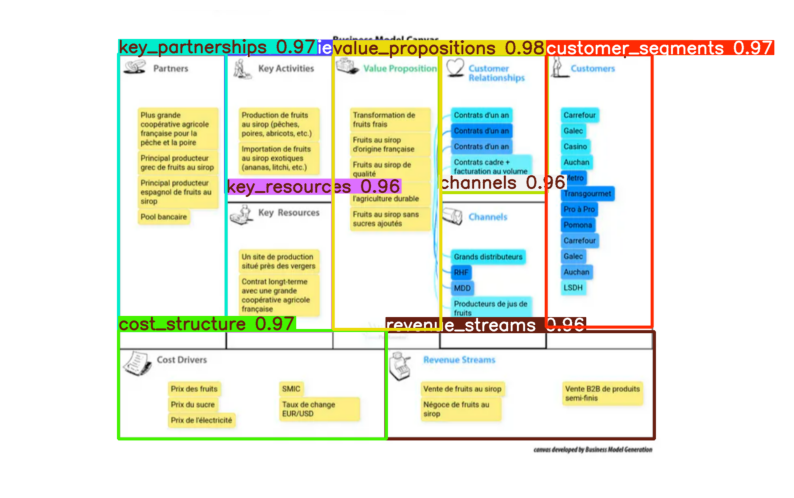

In [22]:
from ultralytics import RTDETR
import cv2
import matplotlib.pyplot as plt

# =========================
# 1) Load trained model
# =========================
MODEL_PATH = "/kaggle/working/bmc_detector_models/rtdetr_l_bmc/weights/best.pt"  

model = RTDETR(MODEL_PATH)

print("Model loaded.")

# =========================
# 2) Image path
# =========================
IMAGE_PATH = "/kaggle/input/datasets/jihenedorgham/testttt/testtttttt.png"  

# =========================
# 3) Run inference
# =========================
results = model(IMAGE_PATH, conf=0.25)

# =========================
# 4) Show results (with boxes)
# =========================
result = results[0]
img = result.plot()   

plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.axis("off")
plt.show()

Model loaded.
Class names: {0: 'customer_segments', 1: 'value_propositions', 2: 'channels', 3: 'customer_relationships', 4: 'revenue_streams', 5: 'key_resources', 6: 'key_activities', 7: 'key_partnerships', 8: 'cost_structure'}

image 1/1 /kaggle/input/datasets/jihenedorgham/testttt/testtttttt.png: 416x640 1 customer_segments, 1 value_propositions, 1 channels, 1 customer_relationships, 1 revenue_streams, 1 key_resources, 1 key_activities, 2 key_partnershipss, 1 cost_structure, 43.6ms
Speed: 2.3ms preprocess, 43.6ms inference, 1.6ms postprocess per image at shape (1, 3, 416, 640)


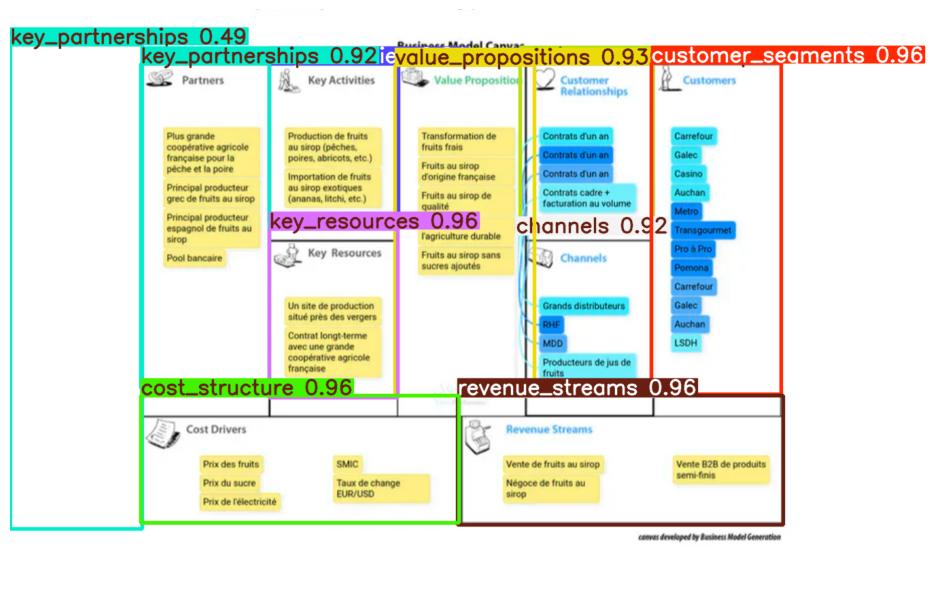

In [24]:
from ultralytics import YOLO
import matplotlib.pyplot as plt

# =========================
# 1) Load YOLO trained model
# =========================
MODEL_PATH = "/kaggle/input/datasets/jihenedorgham/yolov8n/yolov8n_regularized_best.pt"

model = YOLO(MODEL_PATH)

print("Model loaded.")
print("Class names:", model.names)

# =========================
# 2) Image path
# =========================
IMAGE_PATH = "/kaggle/input/datasets/jihenedorgham/testttt/testtttttt.png"

# =========================
# 3) Run inference
# =========================
results = model.predict(
    source=IMAGE_PATH,
    conf=0.25,
    imgsz=640
)

# =========================
# 4) Show results
# =========================
result = results[0]
img = result.plot()

plt.figure(figsize=(12, 12))
plt.imshow(img)
plt.axis("off")
plt.show()

# Detection Visualization (Block Cropping)

To better analyze the model predictions, we extract and visualize each detected BMC block.

For both YOLOv8 and RT-DETR:
- Bounding boxes are used to crop each detected region
- Each crop is saved with its predicted label and confidence score
- Crops are displayed for visual inspection

This step helps:
- verify detection quality
- compare model behavior
- ensure correct localization of BMC blocks

In [46]:
import os

YOLO_CROP_DIR = "/kaggle/working/bmc_crops_yolo"
RTDETR_CROP_DIR = "/kaggle/working/bmc_crops_rtdetr"

os.makedirs(YOLO_CROP_DIR, exist_ok=True)
os.makedirs(RTDETR_CROP_DIR, exist_ok=True)

print("Folders created.")

Folders created.


In [47]:
from ultralytics import YOLO
import cv2
import os

MODEL_PATH = "/kaggle/input/datasets/jihenedorgham/yolov8n/yolov8n_regularized_best.pt"
IMAGE_PATH = "/kaggle/input/datasets/jihenedorgham/testttt/testtttttt.png"

model = YOLO(MODEL_PATH)

results = model.predict(source=IMAGE_PATH, conf=0.25, imgsz=1024)
result = results[0]

image = cv2.imread(IMAGE_PATH)

for i, box in enumerate(result.boxes):
    x1, y1, x2, y2 = map(int, box.xyxy[0])
    cls_id = int(box.cls[0])
    conf = float(box.conf[0])
    label = model.names[cls_id]

    crop = image[y1:y2, x1:x2]

    crop_name = f"yolo_{i}_{label}_{conf:.2f}.png"
    crop_path = os.path.join(YOLO_CROP_DIR, crop_name)

    cv2.imwrite(crop_path, crop)

print("YOLO crops saved.")


image 1/1 /kaggle/input/datasets/jihenedorgham/testttt/testtttttt.png: 640x1024 2 customer_segmentss, 2 channelss, 2 customer_relationshipss, 2 revenue_streamss, 1 key_resources, 1 key_partnerships, 1 cost_structure, 9.5ms
Speed: 5.0ms preprocess, 9.5ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 1024)
✅ YOLO crops saved.


In [49]:
from ultralytics import RTDETR
import cv2
import os

MODEL_PATH = "/kaggle/working/bmc_detector_models/rtdetr_l_bmc/weights/best.pt"
IMAGE_PATH = "/kaggle/input/datasets/jihenedorgham/testttt/testtttttt.png"

model = RTDETR(MODEL_PATH)

results = model(IMAGE_PATH, conf=0.25)
result = results[0]

image = cv2.imread(IMAGE_PATH)

for i, box in enumerate(result.boxes):
    x1, y1, x2, y2 = map(int, box.xyxy[0])
    cls_id = int(box.cls[0])
    conf = float(box.conf[0])
    label = model.names[cls_id]

    crop = image[y1:y2, x1:x2]

    crop_name = f"rtdetr_{i}_{label}_{conf:.2f}.png"
    crop_path = os.path.join(RTDETR_CROP_DIR, crop_name)

    cv2.imwrite(crop_path, crop)

print(" RT-DETR crops saved.")


image 1/1 /kaggle/input/datasets/jihenedorgham/testttt/testtttttt.png: 1024x1024 1 customer_segments, 1 value_propositions, 1 channels, 1 customer_relationships, 1 revenue_streams, 1 key_resources, 1 key_activities, 1 key_partnerships, 1 cost_structure, 95.0ms
Speed: 6.1ms preprocess, 95.0ms inference, 0.8ms postprocess per image at shape (1, 3, 1024, 1024)
✅ RT-DETR crops saved.


🔵 YOLO CROPS


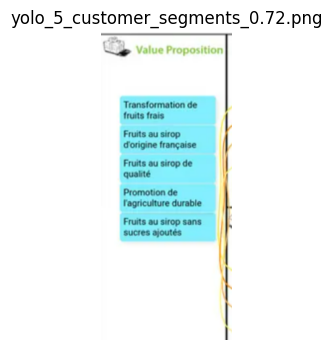

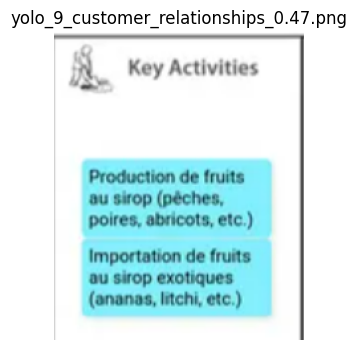

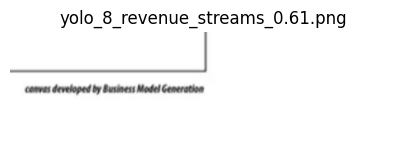

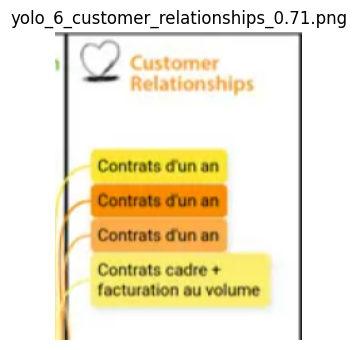

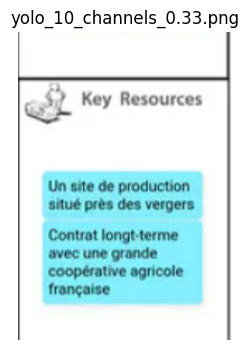

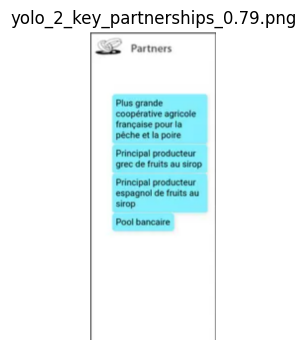

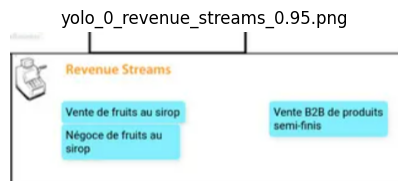

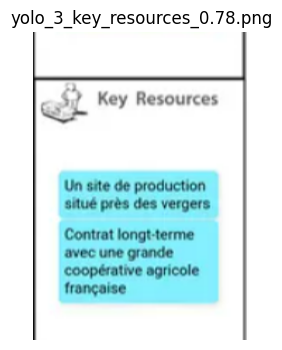

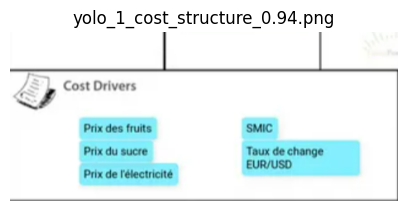

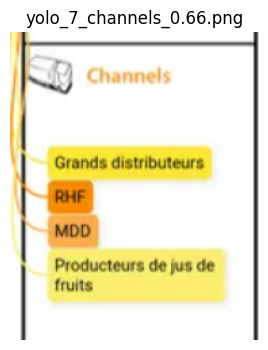

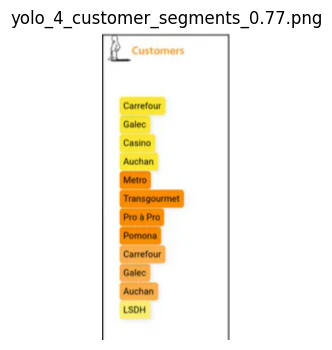

🟠 RT-DETR CROPS


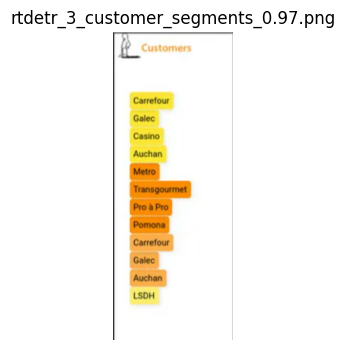

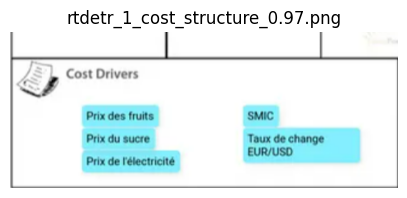

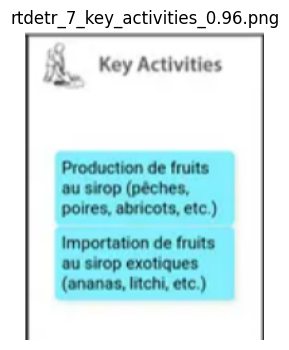

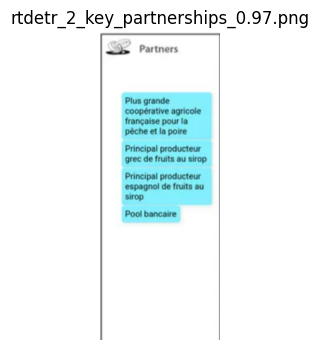

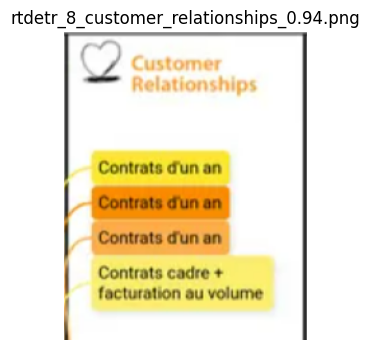

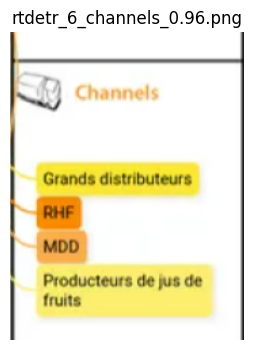

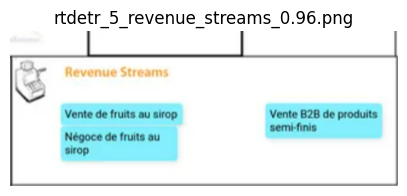

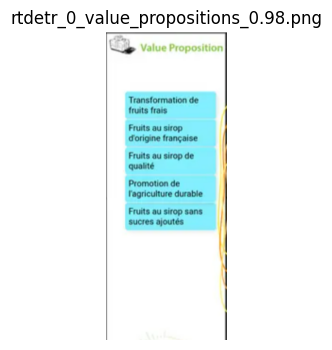

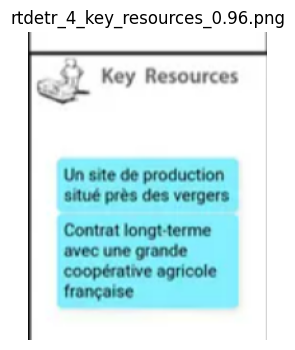

In [50]:
import glob
from PIL import Image
import matplotlib.pyplot as plt

def show_crops(folder):
    paths = glob.glob(f"{folder}/*.png")
    
    for p in paths:
        img = Image.open(p)
        plt.figure(figsize=(5,4))
        plt.imshow(img)
        plt.title(os.path.basename(p))
        plt.axis("off")
        plt.show()

print("🔵 YOLO CROPS")
show_crops(YOLO_CROP_DIR)

print("🟠 RT-DETR CROPS")
show_crops(RTDETR_CROP_DIR)

## Explainable AI (XAI)

In this section, we apply XAI methods to better understand how the detection models make predictions.

For YOLOv8, we use **EigenCAM** to highlight the image regions that strongly influence the model output.

For RT-DETR, we use **occlusion sensitivity**, where parts of the image are hidden and we observe how the detection confidence changes.

These visual explanations help verify whether the models focus on relevant BMC blocks instead of background or irrelevant regions.

In [54]:
!pip install grad-cam -q

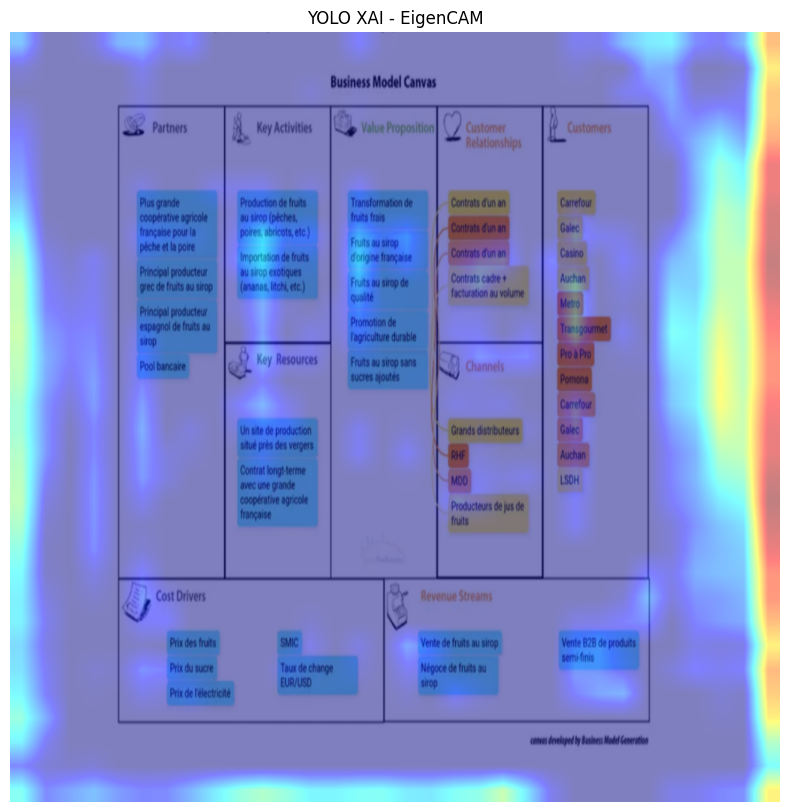

In [55]:
from ultralytics import YOLO
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt

from pytorch_grad_cam import EigenCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

# =========================
# 1) Paths
# =========================
MODEL_PATH = "/kaggle/input/datasets/jihenedorgham/yolov8n/yolov8n_regularized_best.pt"
IMAGE_PATH = "/kaggle/input/datasets/jihenedorgham/testttt/testtttttt.png"

device = "cuda" if torch.cuda.is_available() else "cpu"

# =========================
# 2) Load YOLO
# =========================
yolo = YOLO(MODEL_PATH)
yolo.model.to(device)
yolo.model.eval()

# =========================
# 3) Wrapper to fix YOLO output
# =========================
class YOLOWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        output = self.model(x)

        # YOLO sometimes returns tuple/list
        if isinstance(output, (tuple, list)):
            output = output[0]

        return output

wrapped_model = YOLOWrapper(yolo.model)

# =========================
# 4) Custom target for detection
# =========================
class YOLODetectionTarget:
    def __call__(self, model_output):
        if isinstance(model_output, (tuple, list)):
            model_output = model_output[0]

        # Take strongest detection score
        return model_output.max()

# =========================
# 5) Load image
# =========================
IMG_SIZE = 1024

img = cv2.imread(IMAGE_PATH)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

rgb_img = img_resized.astype(np.float32) / 255.0

input_tensor = torch.from_numpy(rgb_img).permute(2, 0, 1).unsqueeze(0)
input_tensor = input_tensor.float().to(device)

# =========================
# 6) Target layer
# =========================
target_layers = [yolo.model.model[-2]]

# =========================
# 7) EigenCAM
# =========================
cam = EigenCAM(
    model=wrapped_model,
    target_layers=target_layers
)

grayscale_cam = cam(
    input_tensor=input_tensor,
    targets=[YOLODetectionTarget()]
)[0]

visualization = show_cam_on_image(
    rgb_img,
    grayscale_cam,
    use_rgb=True
)

# =========================
# 8) Show result
# =========================
plt.figure(figsize=(10, 10))
plt.imshow(visualization)
plt.axis("off")
plt.title("YOLO XAI - EigenCAM")
plt.show()

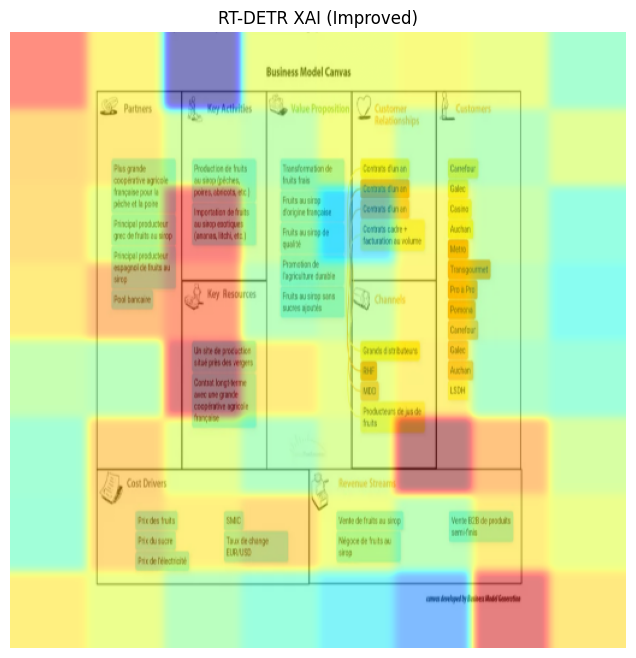

In [4]:
from ultralytics import RTDETR
import numpy as np
import cv2
import matplotlib.pyplot as plt

model = RTDETR("/kaggle/working/bmc_detector_models/rtdetr_l_bmc/weights/best.pt")

image_path = "/kaggle/input/datasets/jihenedorgham/testttt/testtttttt.png"
image = cv2.imread(image_path)

IMG_SIZE = 512
image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

h, w, _ = image.shape
heatmap = np.zeros((h, w))

patch_size = 64 

# baseline score
base_results = model.predict(source=image, conf=0.25, imgsz=512, verbose=False)
base_score = sum(base_results[0].boxes.conf.cpu().numpy())

for y in range(0, h, patch_size):
    for x in range(0, w, patch_size):
        occluded = image.copy()
        occluded[y:y+patch_size, x:x+patch_size] = 0

        results = model.predict(
            source=occluded,
            conf=0.25,
            imgsz=512,
            verbose=False
        )

        score = sum(results[0].boxes.conf.cpu().numpy())

        # importance = how much performance drops
        importance = base_score - score

        heatmap[y:y+patch_size, x:x+patch_size] = importance

# normalize
heatmap = heatmap - heatmap.min()
heatmap = heatmap / (heatmap.max() + 1e-6)

heatmap = cv2.GaussianBlur(heatmap, (21, 21), 0)

# overlay
plt.figure(figsize=(8,8))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.imshow(heatmap, cmap='jet', alpha=0.5)
plt.axis("off")
plt.title("RT-DETR XAI")
plt.show()

In [10]:
!zip -r /kaggle/working/rtdetr_model.zip /kaggle/working/bmc_detector_models/rtdetr_l_bmc/weights

  adding: kaggle/working/bmc_detector_models/rtdetr_l_bmc/weights/ (stored 0%)
  adding: kaggle/working/bmc_detector_models/rtdetr_l_bmc/weights/best.pt (deflated 8%)
  adding: kaggle/working/bmc_detector_models/rtdetr_l_bmc/weights/last.pt (deflated 8%)


In [11]:
!zip /kaggle/working/rtdetr_best_only.zip /kaggle/working/bmc_detector_models/rtdetr_l_bmc/weights/best.pt

  adding: kaggle/working/bmc_detector_models/rtdetr_l_bmc/weights/best.pt (deflated 8%)
